In [1]:
!pip install google-play-scraper vaderSentiment deep-translator matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.6 MB/s eta 0:00:00


In [6]:
from google_play_scraper import reviews, Sort
import csv

In [8]:
result, _ = reviews(
    'com.bpjstku',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=200
)

df = pd.DataFrame(result)
df = df[['userName', 'score', 'at', 'content']]

df.to_csv('ulasan_jmo.csv', index=False)

print("Data berhasil diambil")
df.head()

Data berhasil diambil


,userName,score,at,content
0,Devino Primanda,1,2026-04-29 12:33:49,login saja tidak bisa
1,Riska Permana Wati,5,2026-04-29 11:30:52,Sangat baik
2,Yan Antono,5,2026-04-29 10:20:34,mudah digunakan
3,Teguh Wahyuni,1,2026-04-29 10:06:36,gak bisa di buka di hp Oppo A31 kenapa yah
4,suprapno suprapno,5,2026-04-29 09:11:50,"aplikasi ga bisa dibuka, knapa?"


In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

label_map = {0: 'Positif', 1: 'Netral', 2: 'Negatif'}

def get_sentiment(text):
    if pd.isna(text):
        return 'Netral'

    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    predicted_class_id = torch.argmax(logits, dim=1).item()

    return label_map[predicted_class_id]

df['sentiment'] = df['content'].apply(get_sentiment)

df[['content', 'sentiment']].head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,content,sentiment
0,login saja tidak bisa,Negatif
1,Sangat baik,Positif
2,mudah digunakan,Netral
3,gak bisa di buka di hp Oppo A31 kenapa yah,Negatif
4,"aplikasi ga bisa dibuka, knapa?",Negatif


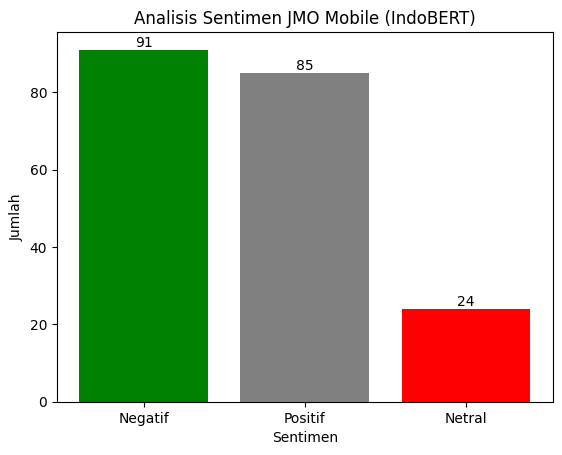

In [11]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

labels = sentiment_counts.index
values = sentiment_counts.values

colors = ['green', 'gray', 'red']

bars = plt.bar(labels, values, color=colors)

plt.title("Analisis Sentimen JMO Mobile (IndoBERT)")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.show()